In [1]:
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc
import platform

# 시스템별 한글 폰트 설정
if platform.system() == 'Windows':
    font_name = font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
    rc('font', family=font_name)
elif platform.system() == 'Darwin':
    rc('font', family='AppleGothic')
else:
    rc('font', family='NanumGothic')

plt.rcParams['axes.unicode_minus'] = False

In [2]:
if platform.system() == 'Windows':
    font_path = "c:/Windows/Fonts/malgun.ttf"
    font_name = font_manager.FontProperties(fname=font_path).get_name()
    rc('font', family=font_name)
elif platform.system() == 'Darwin':
    rc('font', family='AppleGothic')
else:
    rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

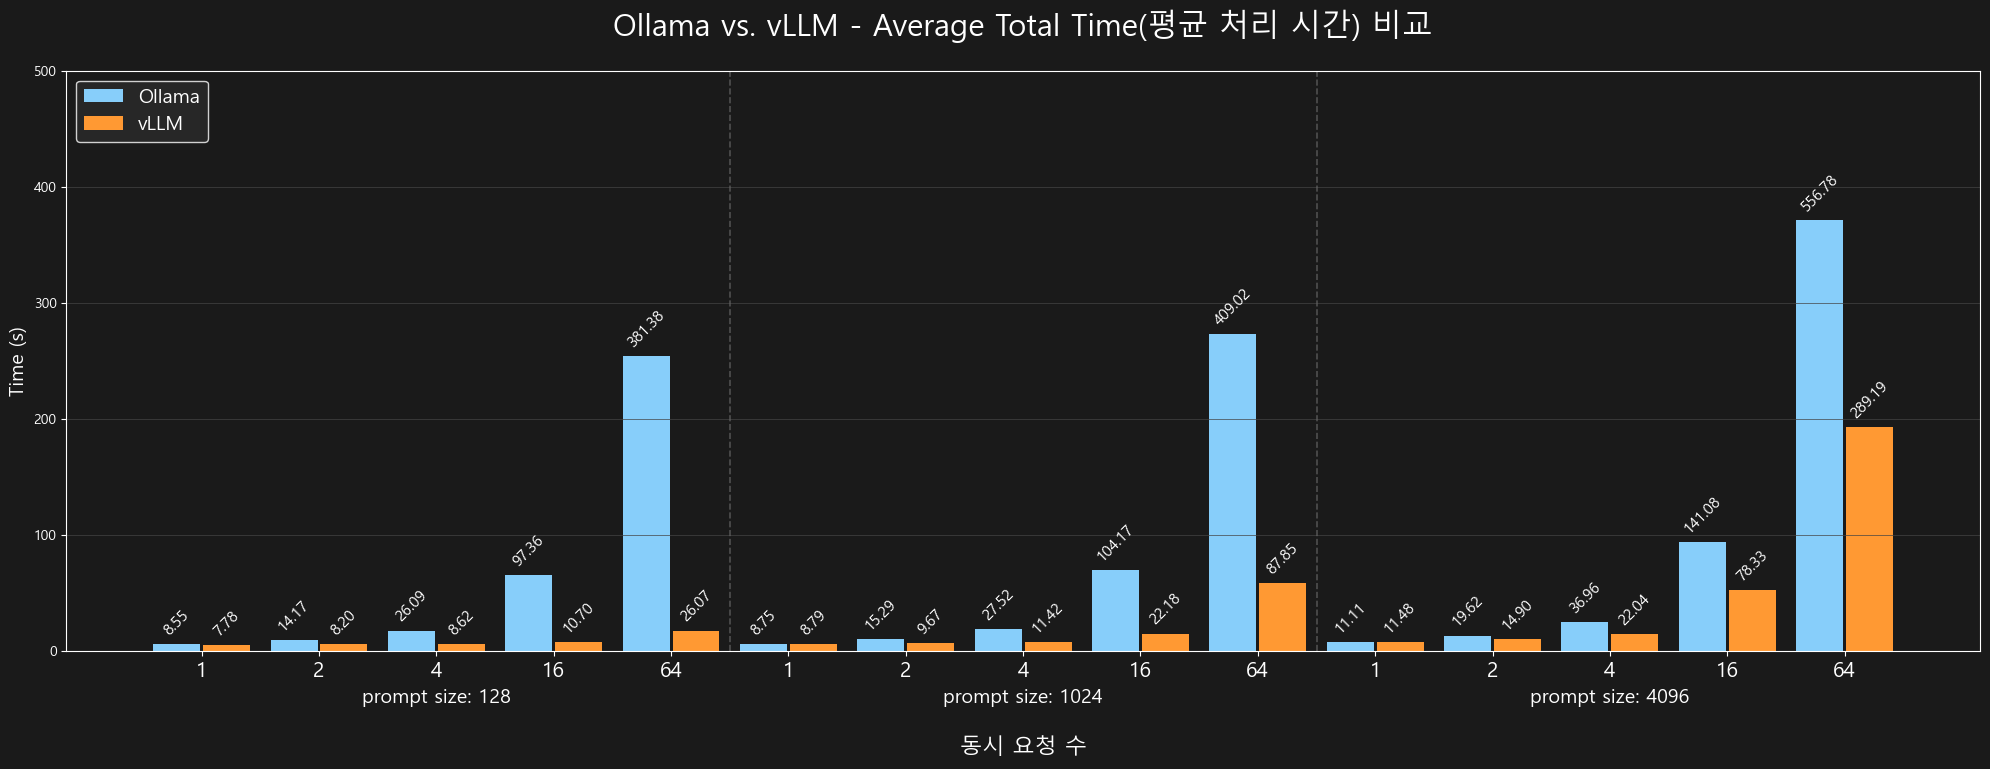

In [3]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

# 1. 데이터 정의
categories = ['1', '2', '4', '16', '64'] * 3

original_ollama = [
    8.55, 14.17, 26.09, 97.36, 381.38,   # 128
    8.75, 15.29, 27.52, 104.17, 409.02,  # 1K
    11.11, 19.62, 36.96, 141.08, 556.78  # 4K
]

original_vllm = [
    7.78, 8.20, 8.62, 10.70, 26.07,      # 128
    8.79, 9.67, 11.42, 22.18, 87.85,     # 1K
    11.48, 14.90, 22.04, 78.33, 289.19   # 4K
]

ollama_data = [x * (2/3) for x in original_ollama]
vllm_data = [x * (2/3) for x in original_vllm]

# ── 너비/간격 설정 ──────────────────────────────
bar_width = 1.6   # 막대 하나의 너비
gap       = 0.1   # 같은 쌍(Ollama↔vLLM) 사이 간격
step      = 4.0   # 그룹 내 막대 쌍 간격
# 조건: 2 * bar_width + gap < step (= 3.2 + 0.1 = 3.3 < 4.0 ✓)
# ───────────────────────────────────────────────

# 그룹을 촘촘하게 — 그룹 간 추가 여백 없이 step 하나만큼만 띄움
g1_start, g2_start, g3_start = 0.0, 20.0, 40.0
group1 = g1_start + np.arange(5) * step   # [0, 4, 8, 12, 16]
group2 = g2_start + np.arange(5) * step   # [20, 24, 28, 32, 36]
group3 = g3_start + np.arange(5) * step   # [40, 44, 48, 52, 56]
x_positions = np.concatenate([group1, group2, group3])

# 그룹별 중심 (프롬프트 라벨용)
g1_center = (group1[0] + group1[-1]) / 2
g2_center = (group2[0] + group2[-1]) / 2
g3_center = (group3[0] + group3[-1]) / 2

# 2. 그래프 스타일
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(20, 8))
fig.patch.set_facecolor('#1a1a1a')
ax.set_facecolor('#1a1a1a')

# 3. 막대 그리기 — gap을 적용해 좌우로 분리
ollama_x = x_positions - gap / 2 - bar_width / 2
vllm_x   = x_positions + gap / 2 + bar_width / 2

bars1 = ax.bar(ollama_x, ollama_data, color='#87CEFA', width=bar_width, label='Ollama')
bars2 = ax.bar(vllm_x,   vllm_data,   color='#FF9933', width=bar_width, label='vLLM')

ax.set_title('Ollama vs. vLLM - Average Total Time(평균 처리 시간) 비교', fontsize=22, color='white', pad=25)
ax.set_ylabel('Time (s)', fontsize=14, color='white')
ax.set_ylim(0, 500)
ax.grid(True, axis='y', color='#444444', linestyle='-', linewidth=0.5)

# 그룹 구분선 (점선)
for sep_x in [18.0, 38.0]:
    ax.axvline(x=sep_x, color='#666666', linestyle='--', linewidth=1.2, alpha=0.7)

# 4. 값 라벨
for i, bar in enumerate(bars1):
    height = bar.get_height()
    ax.annotate(f'{original_ollama[i]:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4), textcoords="offset points",
                ha='center', va='bottom', color='white', fontsize=11, rotation=45)

for i, bar in enumerate(bars2):
    height = bar.get_height()
    ax.annotate(f'{original_vllm[i]:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4), textcoords="offset points",
                ha='center', va='bottom', color='white', fontsize=11, rotation=45)

# 5. X축
ax.set_xticks(x_positions)
ax.set_xticklabels(categories, color='white', fontsize=15)

y_limit = ax.get_ylim()[1]
ax.text(g1_center, -0.09 * y_limit, 'prompt size: 128',  ha='center', color='white', fontsize=14)
ax.text(g2_center, -0.09 * y_limit, 'prompt size: 1024', ha='center', color='white', fontsize=14)
ax.text(g3_center, -0.09 * y_limit, 'prompt size: 4096', ha='center', color='white', fontsize=14)

ax.set_xlabel('동시 요청 수', fontsize=16, color='white', labelpad=40)
ax.legend(loc='upper left', facecolor='#2b2b2b', edgecolor='white', labelcolor='white', fontsize=14)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.show()